In [10]:
import pandas as pd
df=pd.read_csv('/content/cleaned_data.csv')
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases,Age Group
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly,Senior
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly,Young
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly,Adult
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly,Young
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually,Adult


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/cleaned_data.csv')

kpi_1_revenue = df['Purchase Amount (USD)'].sum()
kpi_2_volume = len(df)
kpi_3_aov = df['Purchase Amount (USD)'].mean()
kpi_4_sub_count = df[df['Subscription Status'] == 'Yes']['Customer ID'].nunique()
kpi_5_sub_mix = (kpi_4_sub_count / df['Customer ID'].nunique()) * 100

print("=========================================================")
print("            PART 1: METRIC KEYS & KEY KPIs              ")
print("=========================================================")
print(f"KPI 1 (Total Revenue)          : ${kpi_1_revenue:,.2f}")
print(f"KPI 2 (Transaction Volume)     : {kpi_2_volume:,}")
print(f"KPI 3 (Average Order Value)    : ${kpi_3_aov:.2f}")
print(f"KPI 4 (Premium Member Count)   : {kpi_4_sub_count:,}")
print(f"KPI 5 (Subscriber Mix Share)   : {kpi_5_sub_mix:.2f}%")
print("=========================================================\n")

            PART 1: METRIC KEYS & KEY KPIs              
KPI 1 (Total Revenue)          : $233,081.00
KPI 2 (Transaction Volume)     : 3,900
KPI 3 (Average Order Value)    : $59.76
KPI 4 (Premium Member Count)   : 1,053
KPI 5 (Subscriber Mix Share)   : 27.00%



In [13]:
print("Processing Part 2: Constructing behavioral customer segments...")

customer_profile = df.groupby('Customer ID').agg(
    Total_Spend=('Purchase Amount (USD)', 'sum'),
    Frequency=('Purchase Amount (USD)', 'count'),
    Avg_Rating=('Review Rating', 'mean')
).reset_index()

def segment_customers(row):
    if row['Total_Spend'] >= 85:
        return 'High-Value VIP'
    elif row['Total_Spend'] >= 50:
        return 'Stable Core'
    else:
        return 'Casual/Occasional'

customer_profile['Customer_Segment'] = customer_profile.apply(segment_customers, axis=1)
df_segmented = df.merge(customer_profile[['Customer ID', 'Customer_Segment']], on='Customer ID', how='left')

print("Segment Mapping Counts:")
print(df_segmented['Customer_Segment'].value_counts())
print("\n")

Processing Part 2: Constructing behavioral customer segments...
Segment Mapping Counts:
Customer_Segment
Stable Core          1655
Casual/Occasional    1466
High-Value VIP        779
Name: count, dtype: int64




Processing Part 3: Rendering corporate dashboard visuals...


/tmp/ipykernel_6594/3178340579.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


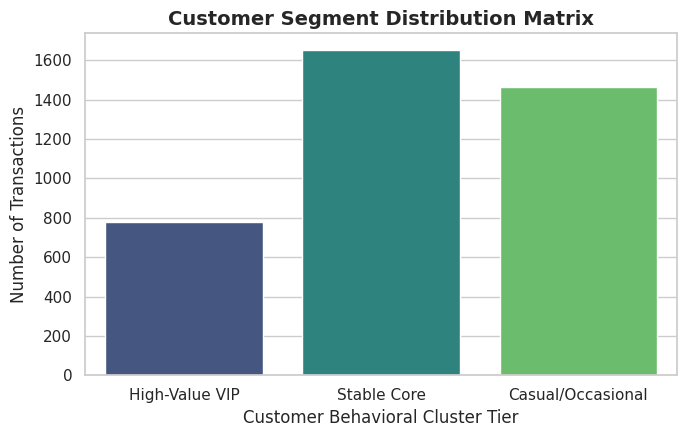

In [14]:
print("Processing Part 3: Rendering corporate dashboard visuals...")

sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})

plt.figure(figsize=(7, 4.5))
sns.countplot(
    data=df_segmented,
    x='Customer_Segment',
    palette='viridis',
    order=['High-Value VIP', 'Stable Core', 'Casual/Occasional']
)
plt.title('Customer Segment Distribution Matrix', weight='bold')
plt.xlabel('Customer Behavioral Cluster Tier')
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.savefig('Task3_Segment_Distribution.png', dpi=300)
plt.show()
plt.close()



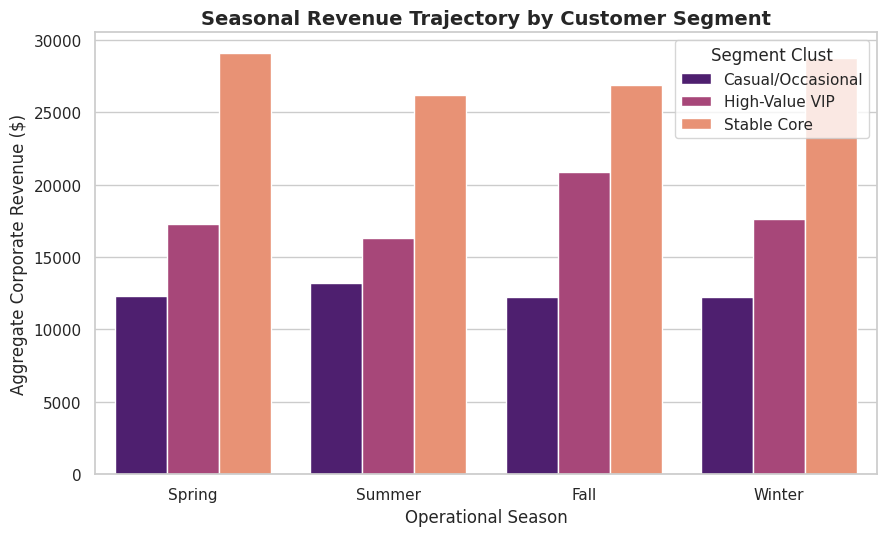

In [15]:
plt.figure(figsize=(9, 5.5))
seasonal_rev = df_segmented.groupby(['Season', 'Customer_Segment'])['Purchase Amount (USD)'].sum().reset_index()
sns.barplot(
    data=seasonal_rev,
    x='Season',
    y='Purchase Amount (USD)',
    hue='Customer_Segment',
    palette='magma',
    order=['Spring', 'Summer', 'Fall', 'Winter']
)
plt.title('Seasonal Revenue Trajectory by Customer Segment', weight='bold')
plt.xlabel('Operational Season')
plt.ylabel('Aggregate Corporate Revenue ($)')
plt.legend(title='Segment Clust')
plt.tight_layout()
plt.savefig('Task3_Seasonal_Trends.png', dpi=300)
plt.show()
plt.close()

In [16]:
print("Processing Part 4: Building cross-tabs and exporting files...")

deep_dive_summary = df_segmented.groupby(['Customer_Segment', 'Season', 'Category']).agg(
    Segment_Revenue=('Purchase Amount (USD)', 'sum'),
    Transaction_Count=('Purchase Amount (USD)', 'count'),
    Avg_Transaction_Value=('Purchase Amount (USD)', 'mean'),
    Avg_Customer_Satisfaction=('Review Rating', 'mean')
).reset_index()

deep_dive_summary = deep_dive_summary.sort_values(by=['Customer_Segment', 'Segment_Revenue'], ascending=[True, False])

print("=========================================================")
print("        DEEP-DIVE STRATEGIC MATRICES (TOP RECORDS)      ")
print("=========================================================")
print(deep_dive_summary.head(10).to_string(index=False))
print("=========================================================\n")

df_segmented.to_csv('Task3_BI_Ready_Master.csv', index=False)
deep_dive_summary.to_csv('Task3_Deep_Dive_Segmentation.csv', index=False)

print("Task 3 core programming completely finalized!")

Processing Part 4: Building cross-tabs and exporting files...
        DEEP-DIVE STRATEGIC MATRICES (TOP RECORDS)      
 Customer_Segment Season    Category  Segment_Revenue  Transaction_Count  Avg_Transaction_Value  Avg_Customer_Satisfaction
Casual/Occasional Summer    Clothing             5963                176              33.880682                   3.678409
Casual/Occasional   Fall    Clothing             5351                156              34.301282                   3.711538
Casual/Occasional Spring    Clothing             5298                159              33.320755                   3.668553
Casual/Occasional Winter    Clothing             5203                153              34.006536                   3.687582
Casual/Occasional   Fall Accessories             4156                118              35.220339                   3.822034
Casual/Occasional Winter Accessories             4031                114              35.359649                   3.795614
Casual/Occasional Sp